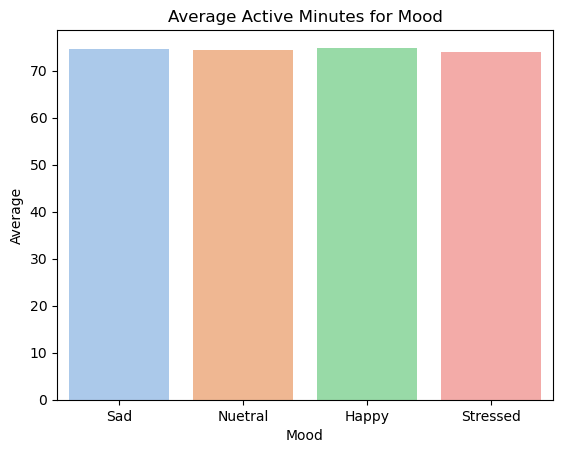

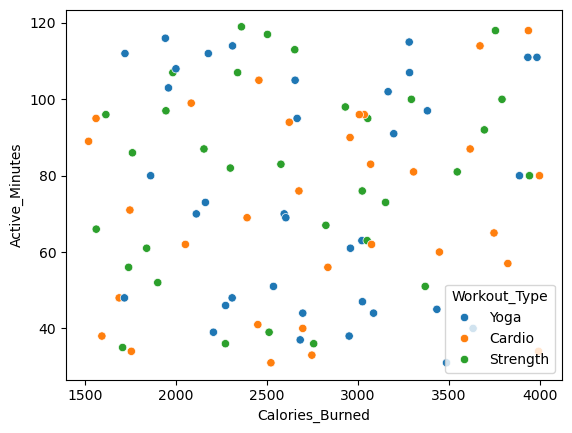

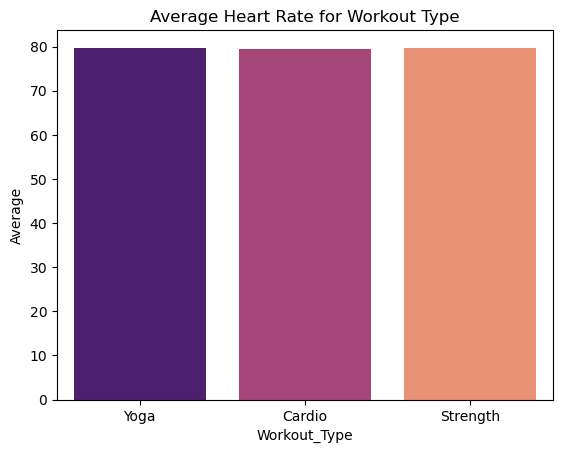

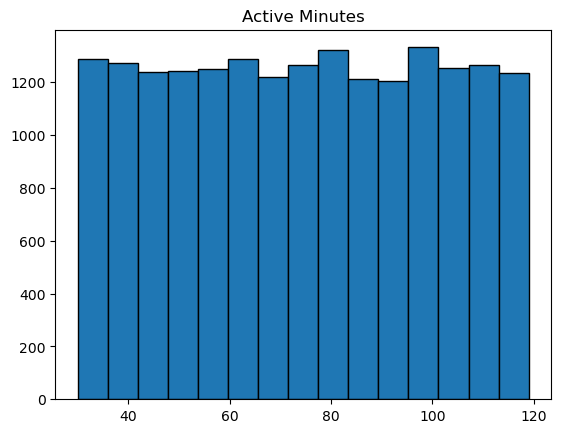

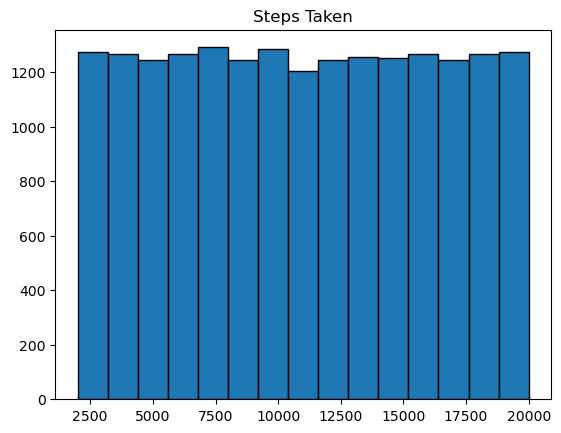

,User_ID,Age,Height (cm),Weight (kg),Steps_Taken,Calories_Burned,Hours_Slept,Water_Intake (Liters),Active_Minutes,Heart_Rate (bpm),Stress_Level (1-10)
User_ID,1.000000,0.164855,-0.047510,-0.102745,-0.001462,0.003316,0.004196,-0.009210,-0.006301,-0.010787,0.003395
Age,0.164855,1.000000,-0.123327,0.003924,-0.002524,0.004672,-0.001244,-0.004047,0.006315,-0.005252,-0.008983
Height (cm),-0.047510,-0.123327,1.000000,-0.045111,-0.008695,0.007365,0.006085,0.002000,-0.010104,0.000088,-0.001821
Weight (kg),-0.102745,0.003924,-0.045111,1.000000,0.009250,0.004445,0.004415,0.000664,0.001133,-0.004339,-0.004025
Steps_Taken,-0.001462,-0.002524,-0.008695,0.009250,1.000000,0.006626,0.000980,0.003763,0.000459,0.005483,0.001241
Calories_Burned,0.003316,0.004672,0.007365,0.004445,0.006626,1.000000,0.009527,0.006076,-0.003144,-0.002404,0.000644
Hours_Slept,0.004196,-0.001244,0.006085,0.004415,0.000980,0.009527,1.000000,-0.005794,-0.000029,0.003159,-0.002227
Water_Intake (Liters),-0.009210,-0.004047,0.002000,0.000664,0.003763,0.006076,-0.005794,1.000000,-0.002399,0.002660,0.001603
Active_Minutes,-0.006301,0.006315,-0.010104,0.001133,0.000459,-0.003144,-0.000029,-0.002399,1.000000,0.008642,0.001612
Heart_Rate (bpm),-0.010787,-0.005252,0.000088,-0.004339,0.005483,-0.002404,0.003159,0.002660,0.008642,1.000000,0.008544


In [4]:

#importing libraries

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

#=============================================================================================================

#loading dataset

df = pd.read_excel('Fitness_Health_Tracking_Dataset_with_Missing_Values.xlsx')
df_cleaned = df.dropna()

#=============================================================================================================

#Question: How does activity hours affect mood?

#average activity minutes based on mood bar graph

def getAverage(mood):# gets average minutes of every mood to display in bar graph
    total = 0 #gets average minutes of every mood to display in bar graph
    i = 0 #variable to hold all heart rates added together
    array = df_cleaned[['Mood', 'Active_Minutes']].to_numpy() #only using the two columns needed
    for value in array: #iterating through array
        if value[0] == mood: #finding correct workout
            minutes = int(value[1]) #minutes
            total = total + minutes #total minutes of all people
            i = i + 1 #counting how many people
    if i == 0: #does not allow division by zero
        return 0
    average = total/i
    return average

#getting all averages
sad_average = getAverage('Sad')
nuetral_average = (getAverage('Neutral'))
happy_average = (getAverage('Happy'))
stressed_average = (getAverage('Stressed'))

#putting data into new dataframe for graphing
df_average_mood = pd.DataFrame({
    'Mood': ['Sad', 'Nuetral', 'Happy', 'Stressed'],
    'Average': [sad_average, nuetral_average, happy_average, stressed_average]
})

#plot and display
sns.barplot(data=df_average_mood, x='Mood', y='Average', hue='Mood', palette='pastel')
plt.title("Average Active Minutes for Mood")
plt.show()

#=============================================================================================================

#Question: How does workout type affect calories burned?

sns.scatterplot(df_cleaned.head(100), x='Calories_Burned', y='Active_Minutes', hue='Workout_Type')
plt.show()

#=============================================================================================================

#Question: How does workout type affect heartrate?

def getAverageHeartRate(workout): #gets average minutes of every mood to display in bar graph
    total = 0 #variable to hold all heart rates added together
    i = 0 #variable to count how many people in total
    array = df_cleaned[['Workout_Type', 'Heart_Rate (bpm)']].to_numpy() #only using the two columns needed
    for value in array: #iterating through array
        if value[0] == workout: #finding correct workout
            heart_rate = int(value[1]) #heart rate 
            total = total + heart_rate #adding all together
            i = i + 1 #counting how many people
    if i == 0: #does not allow division by zero
        return 0
    average = total/i
    return average

#getting all averages
yoga_average = getAverageHeartRate('Yoga')
cardio_average = getAverageHeartRate('Cardio')
strength_average = getAverageHeartRate('Strength')

#putting data into new dataframe for graphing
df_average_workout = pd.DataFrame({
    'Workout_Type': ['Yoga', 'Cardio', 'Strength'],
    'Average': [yoga_average, cardio_average, strength_average]
})

#plot and display
sns.barplot(data=df_average_workout, x='Workout_Type', y='Average', hue='Workout_Type', palette='magma')
plt.title("Average Heart Rate for Workout Type")
plt.show()

#=============================================================================================================


#Active Minutes

plt.hist(data=df_cleaned, x='Active_Minutes', edgecolor='black', bins=15)
plt.title('Active Minutes')
plt.show()

#=============================================================================================================

#Steps Taken

plt.hist(data=df_cleaned, x='Steps_Taken', edgecolor='black', bins=15)
plt.title('Steps Taken')
plt.show()

#=============================================================================================================

#This further proves that this is synthetic data

# Check correlations for numeric columns
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()
corr

#=============================================================================================================



